# Data Preprocessing

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard # tool to visulize the metrics.

In [3]:
(x_train, y_train), (x_test, y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

# Normalizing DataSet

In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

In [6]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Building CNN

In [7]:
cnn_model = Sequential([
    Conv2D(32, kernel_size= (3,3), activation= 'relu', input_shape= (28, 28, 1)),
    MaxPooling2D(pool_size= (2,2)),
    Conv2D(64, kernel_size= (3,3), activation= 'relu'), # applied to introduce non-linearly.
    MaxPooling2D(pool_size= (2,2)),
    Flatten(),
    Dense(128, activation= 'relu'), # 128 neurons with non-linearlity.
    Dropout(0.5), # rand drops 50% neurons during traning.
    Dense(10, activation= 'softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
cnn_model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Traning the Model

In [9]:
train_cnn_model = cnn_model.fit(x_train, y_train, batch_size= 128, epochs= 5, validation_data= (x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.7937 - loss: 0.6500 - val_accuracy: 0.9774 - val_loss: 0.0739
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9685 - loss: 0.1105 - val_accuracy: 0.9860 - val_loss: 0.0437
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9771 - loss: 0.0767 - val_accuracy: 0.9885 - val_loss: 0.0354
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9806 - loss: 0.0614 - val_accuracy: 0.9898 - val_loss: 0.0301
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9836 - loss: 0.0538 - val_accuracy: 0.9906 - val_loss: 0.0278


In [10]:
# Defining tensorboard callback.
TensorBoard_callback = TensorBoard(log_dir= 'logs') # It will create a directory 'log' to save info.
# Retrain the model.
cnn_model.fit(x_train, y_train, validation_data= (x_test, y_test), epochs= 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9779 - loss: 0.0735 - val_accuracy: 0.9894 - val_loss: 0.0326
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9850 - loss: 0.0474 - val_accuracy: 0.9906 - val_loss: 0.0289
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9894 - loss: 0.0378 - val_accuracy: 0.9899 - val_loss: 0.0320
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.9925 - val_loss: 0.0222
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.9906 - val_loss: 0.0285


# Predicting Actual vs Predicting.

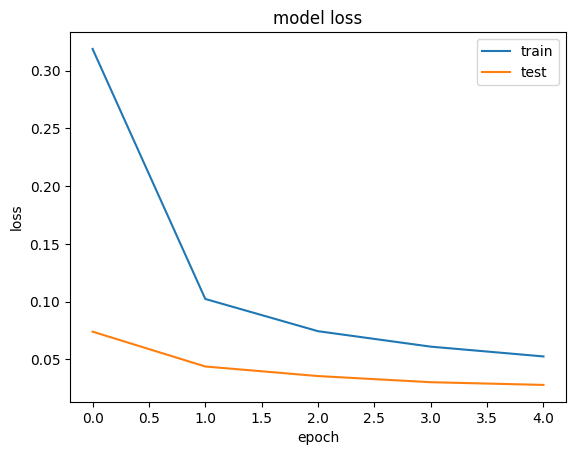

In [17]:
plt.plot(train_cnn_model.history['loss'])
plt.plot(train_cnn_model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc= 'upper right')
plt.show()

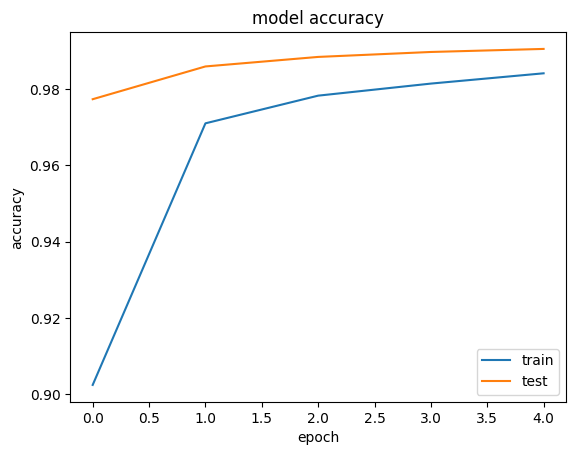

In [19]:
plt.plot(train_cnn_model.history['accuracy'])
plt.plot(train_cnn_model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc= 'lower right')
plt.show()

In [14]:
predicted_model = cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


# Visulizing Actual and Predicting Image

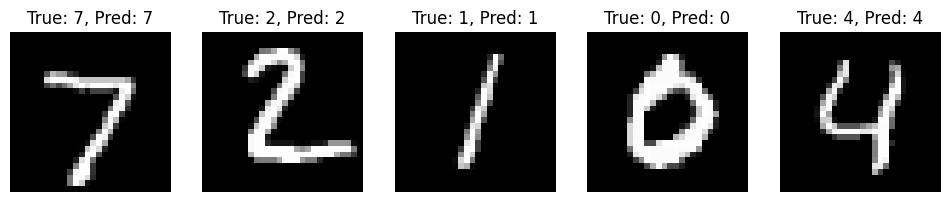

In [16]:
def plot_img(images, true_labels, pred_labels):
    plt.figure(figsize= (12, 5))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap= 'gray')
        plt.title(f"True: {true_labels[i]}, Pred: {pred_labels[i]}")
        plt.axis('off') # Removes the x and y-axis.
    plt.show()

plot_img(x_test[:5], y_test[:5], np.argmax(predicted_model[:5], axis=1))